<a href="https://colab.research.google.com/github/Phantom-dcode/reasoning-preserving-quantization/blob/research/Copy_of_Document_from_L%C3%B8gesh_%F0%9F%90%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Reasoning-Preserving Low-Bit Quantization for Edge Language Models
### Sensitivity-Aware Mixed Precision, Verification-Gated Fallback, and Reasoning-Calibrated PTQ
**(v3 — every cell is independently resumable; fixes all previously reported errors)**

**Runtime:** Google Colab Free Tier (T4 GPU) — Runtime > Change runtime type > GPU

**Every fix applied in this version, and why it was needed:**

1. **`ModuleNotFoundError: No module named 'bitsandbytes'`** — old exact version pins
   (`bitsandbytes==0.43.1`, `transformers==4.44.2`) don't have wheels for current Colab images.
   Fixed: install latest unpinned versions, verify the import actually works, auto-restart the
   kernel only if needed.
2. **`RuntimeError: quantile() input tensor must be either float or double dtype`** — activations
   were captured in fp16; `torch.quantile` requires float32/float64. Fixed: `.float()` added
   before `.cpu()` when caching activations.
3. **`NameError` / `KeyError: '_shared'`** — cells relied on Python variables set by *other*
   cells earlier in the same kernel session. Any kernel restart (including the automatic one from
   fix #1) wipes those variables even though the checkpoint file on Drive still has the data.
   Fixed: **every single cell below reloads `checkpoint = load_checkpoint()` from disk as its
   first line**, and recomputes any derived value (`sensitivities`, `ranked_layers`,
   `high_precision_layers`, `reasoning_clip_ranges`, `generic_clip_ranges`) from that checkpoint
   rather than trusting an in-memory variable. This makes the notebook safe to run **in any
   order, after any restart, any number of times** — you never need to remember which earlier
   cell to re-run first.
4. **`AssertionError` in bitsandbytes (`assert module.weight.shape[1] == 1`)** — passing a custom
   `llm_int8_skip_modules` list **replaces** transformers' default skip list, which normally
   protects `lm_head` (its weight is tied to the embedding layer; quantizing it corrupts that
   shared state). Fixed: `load_4bit()` now always includes `"lm_head"` in the skip list, whether
   or not you also pass sensitivity-protected decoder layers.

**How to use this notebook:** just run cells top to bottom. If Colab disconnects, the kernel
restarts, or you hit a daily GPU quota, simply re-run from the top — every cell checks Drive
first and skips whatever is already done.


## 0. Mount Drive and set up the resumable checkpoint (run this cell first, always)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

PROJECT_DIR = "/content/drive/MyDrive/reasoning_preserving_quantization"
os.makedirs(PROJECT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(PROJECT_DIR, "checkpoint_results.json")

def load_checkpoint():
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, "r") as f:
            return json.load(f)
    return {}

def save_checkpoint(results_dict):
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump(results_dict, f, indent=2)

def get_shared(checkpoint, key, section_hint):
    """Fetch a value computed in Section 4 with a clear, actionable error instead of a
    cryptic KeyError if that section has not been completed and saved yet."""
    if "_shared" not in checkpoint or key not in checkpoint["_shared"]:
        raise RuntimeError(
            f"'{key}' is not in the checkpoint yet. Scroll up and run {section_hint} first "
            f"(it saves its output to Drive, and every cell in this notebook reloads from "
            f"there automatically)."
        )
    return checkpoint["_shared"][key]

checkpoint = load_checkpoint()
print(f"Project folder: {PROJECT_DIR}")
print(f"Loaded checkpoint with {len(checkpoint)} top-level key(s):", list(checkpoint.keys()))

Mounted at /content/drive
Project folder: /content/drive/MyDrive/reasoning_preserving_quantization
Loaded checkpoint with 5 top-level key(s): ['full_precision_fp16', '_shared', 'uniform_4bit_baseline', 'contribution3_reasoning_calibrated_4bit', 'control_generic_calibrated_4bit']


## 1. Environment setup (fix #1: unpinned install + verified + auto-restart if needed)

In [ ]:
import sys, subprocess, os

def pip_install(*packages):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", *packages], check=True)

def bitsandbytes_ready():
    try:
        import bitsandbytes as bnb
        print(f"bitsandbytes {bnb.__version__} is importable.")
        return True
    except ImportError:
        return False

if bitsandbytes_ready():
    pip_install("transformers", "datasets", "accelerate", "sentencepiece")
    print("Install complete.")
else:
    print("Installing/upgrading dependencies (unpinned, latest-compatible versions)...")
    pip_install("transformers", "datasets", "accelerate", "sentencepiece", "bitsandbytes")
    if bitsandbytes_ready():
        print("Install complete -- bitsandbytes loaded without needing a restart.")
    else:
        print("bitsandbytes installed but needs a kernel restart to load its compiled "
              "extension. Restarting automatically now.\n"
              "AFTER THE RESTART: just re-run this notebook from the top (Runtime > Run all). "
              "The Drive checkpoint will skip every configuration already completed.")
        os.kill(os.getpid(), 9)

Installing/upgrading dependencies (unpinned, latest-compatible versions)...
bitsandbytes 0.50.2 is importable.
Install complete -- bitsandbytes loaded without needing a restart.


In [ ]:
import torch, re, time, statistics, gc
import numpy as np
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU detected. Runtime > Change runtime type > GPU.")

def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

CUDA available: True
Device: Tesla T4
GPU memory: 15.6 GB


## 2. Data acquisition (public, programmatic — deterministic, so it's identical after any restart)

- **GSM8K** (Cobbe et al., 2021; HuggingFace Hub `openai/gsm8k`, `main` config).
- A disjoint sample of GSM8K training-set chain-of-thought traces is the reasoning calibration
  set (Contribution 3 / sensitivity probe). A separate disjoint sample of questions-only text is
  the generic-calibration control.

**Note on scale:** `N_EVAL` is kept modest (40) to fit comfortably inside the free-tier T4 daily
quota across all 7 configurations plus the ablation. Raise it once the full pipeline has run
cleanly end-to-end at least once.


In [ ]:
from datasets import load_dataset
import random
random.seed(42)   # fixed seed -- eval_set/calib sets are identical every time this cell runs

gsm8k = load_dataset("openai/gsm8k", "main")

N_EVAL = 40
N_CALIB = 30

test_examples = list(gsm8k["test"]); random.shuffle(test_examples)
eval_set = test_examples[:N_EVAL]

train_examples = list(gsm8k["train"]); random.shuffle(train_examples)
calib_reasoning_traces = [ex["answer"] for ex in train_examples[:N_CALIB]]
generic_calib_text = [ex["question"] for ex in train_examples[N_CALIB:N_CALIB*2]]

print(f"Eval examples: {len(eval_set)}, reasoning-calib traces: {len(calib_reasoning_traces)}, generic-calib texts: {len(generic_calib_text)}")

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.31MB            

main/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

main/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  419kB            

main/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Eval examples: 40, reasoning-calib traces: 30, generic-calib texts: 30


In [ ]:
def extract_gold_answer(answer_field):
    return answer_field.split("####")[-1].strip().replace(",", "")

def extract_pred_answer(generated_text):
    nums = re.findall(r'-?\d[\d,]*\.?\d*', generated_text.replace(",", ""))
    return nums[-1].rstrip(".") if nums else None

def is_correct(pred, gold):
    try:
        return abs(float(pred) - float(gold)) < 1e-3
    except (TypeError, ValueError):
        return False

## 3. Model loading utilities (fix #4: `lm_head` always protected from quantization)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def load_fp16():
    return AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")

def load_4bit(skip_layer_ids=None):
    """Loads in 4-bit. `lm_head` is ALWAYS included in the skip list -- transformers protects
    it by default because its weight is tied to the embedding layer, and a custom
    llm_int8_skip_modules list REPLACES the default rather than extending it. Omitting lm_head
    here previously caused:
        AssertionError: assert module.weight.shape[1] == 1
    inside bitsandbytes during generation. If skip_layer_ids is given, those decoder blocks are
    ALSO loaded in fp16 instead of being quantized (bitsandbytes' native mixed-precision
    mechanism -- this avoids re-casting an already-quantized module after the fact, which
    corrupts bitsandbytes' packed 4-bit weight format)."""
    skip_modules = ["lm_head"]
    if skip_layer_ids:
        skip_modules += [f"layers.{i}." for i in skip_layer_ids]   # trailing dot avoids "layers.1." matching "layers.10."
    cfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                              bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
                              llm_int8_skip_modules=skip_modules)
    return AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=cfg, device_map="auto")

def load_8bit():
    cfg = BitsAndBytesConfig(load_in_8bit=True, llm_int8_skip_modules=["lm_head"])
    return AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=cfg, device_map="auto")

def model_memory_footprint_gb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1e9

def generate_answer(model, question, max_new_tokens=220):
    prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": f"Solve step by step, then give the final numeric answer on its own line.\n\n{question}"}],
        tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    t0 = time.perf_counter()
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                          pad_token_id=tokenizer.eos_token_id)
    gen_s = time.perf_counter() - t0
    text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return text, gen_s

def evaluate_model(model, examples, label):
    results = []
    for ex in examples:
        gold = extract_gold_answer(ex["answer"])
        gen_text, gen_s = generate_answer(model, ex["question"])
        pred = extract_pred_answer(gen_text)
        results.append({"correct": is_correct(pred, gold), "gen_s": gen_s,
                         "cot_len_tokens": len(tokenizer(gen_text)["input_ids"])})
    acc = 100 * sum(r["correct"] for r in results) / len(results)
    mean_len = statistics.mean(r["cot_len_tokens"] for r in results)
    mean_time = statistics.mean(r["gen_s"] for r in results)
    print(f"[{label}] accuracy={acc:.1f}%  mean_cot_tokens={mean_len:.1f}  mean_gen_s={mean_time:.2f}")
    return {"accuracy": acc, "mean_cot_tokens": mean_len, "mean_gen_s": mean_time}

def verify_arithmetic_consistency(cot_text):
    pattern = re.findall(r'(-?\d+\.?\d*)\s*([+\-*/x])\s*(-?\d+\.?\d*)\s*=\s*(-?\d+\.?\d*)', cot_text)
    if not pattern:
        return True
    for a, op, b, c in pattern:
        try:
            a, b, c = float(a), float(b), float(c)
            op = '*' if op == 'x' else op
            result = {'+': a + b, '-': a - b, '*': a * b, '/': a / b if b != 0 else None}[op]
            if result is None or abs(result - c) > 1e-2:
                return False
        except (ValueError, ZeroDivisionError):
            continue
    return True

def evaluate_verification_gated(fast_model, examples, label):
    results, n_escalated, slow_model = [], 0, None
    for ex in examples:
        gold = extract_gold_answer(ex["answer"])
        gen_text, gen_s = generate_answer(fast_model, ex["question"])
        verified = verify_arithmetic_consistency(gen_text)
        total_s = gen_s
        if not verified:
            n_escalated += 1
            if slow_model is None:
                print("  Escalation triggered -- loading 8-bit model...")
                slow_model = load_8bit()
            gen_text, gen_s2 = generate_answer(slow_model, ex["question"])
            total_s += gen_s2
        pred = extract_pred_answer(gen_text)
        results.append({"correct": is_correct(pred, gold), "gen_s": total_s, "escalated": not verified})
    if slow_model is not None:
        del slow_model
        free_gpu()
    acc = 100 * sum(r["correct"] for r in results) / len(results)
    mean_time = statistics.mean(r["gen_s"] for r in results)
    escalation_rate = 100 * n_escalated / len(examples)
    print(f"[{label}] accuracy={acc:.1f}%  mean_gen_s={mean_time:.2f}  escalation_rate={escalation_rate:.1f}%")
    return {"accuracy": acc, "mean_gen_s": mean_time, "escalation_rate": escalation_rate}

def install_activation_clamps(model, clip_ranges):
    handles = []
    for idx, layer in enumerate(model.model.layers):
        clip_val = clip_ranges.get(f"layer_{idx}")
        if clip_val is None:
            continue
        def make_hook(cv):
            def hook(module, inp, out):
                if isinstance(out, tuple):
                    return (torch.clamp(out[0], -cv, cv),) + out[1:]
                return torch.clamp(out, -cv, cv)
            return hook
        handles.append(layer.register_forward_hook(make_hook(clip_val)))
    return handles

def remove_hooks(handles):
    for h in handles:
        h.remove()

print("Model loading utilities defined.")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Model loading utilities defined.


## 4. Baseline (full precision) + sensitivity probe + calibration ranges — ONE fp16 load

Loads the fp16 model once and reuses it for the baseline eval, the sensitivity probe, and both
calibration-range computations (fix #2 applied inside `compute_activation_clip_ranges`), then
frees it. This cell is idempotent: re-running it after any restart reloads `checkpoint` from
disk first and skips anything already saved.


In [ ]:
@torch.no_grad()
def measure_layer_sensitivity(model, calib_traces, noise_std=0.02, n_probe=12):
    device = next(model.parameters()).device
    probe_traces = calib_traces[:n_probe]
    tokenized = [tokenizer(t, return_tensors="pt", truncation=True, max_length=200).to(device)
                 for t in probe_traces]

    def base_loss():
        losses = []
        for enc in tokenized:
            out = model(**enc, labels=enc["input_ids"])
            losses.append(out.loss.item())
        return statistics.mean(losses)

    baseline_loss = base_loss()
    sensitivities = []
    layers = model.model.layers
    for idx in range(len(layers)):
        def hook(module, inp, out, std=noise_std):
            if isinstance(out, tuple):
                hidden = out[0] + torch.randn_like(out[0]) * std * out[0].std()
                return (hidden,) + out[1:]
            return out + torch.randn_like(out) * std * out.std()
        handle = layers[idx].register_forward_hook(hook)
        noisy_loss = base_loss()
        handle.remove()
        sensitivities.append(noisy_loss - baseline_loss)
    return sensitivities

@torch.no_grad()
def compute_activation_clip_ranges(model, calib_texts, percentile=99.5):
    device = next(model.parameters()).device
    activations, hooks = {}, []
    def make_hook(name):
        def hook(module, inp, out):
            val = out[0] if isinstance(out, tuple) else out
            # FIX #2: .float() required -- torch.quantile does not support float16 input.
            activations.setdefault(name, []).append(val.detach().abs().flatten().float().cpu())
        return hook
    for idx, layer in enumerate(model.model.layers):
        hooks.append(layer.register_forward_hook(make_hook(f"layer_{idx}")))
    for text in calib_texts:
        enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=200).to(device)
        model(**enc)
    for h in hooks:
        h.remove()
    return {name: torch.quantile(torch.cat(vals), percentile / 100).item()
            for name, vals in activations.items()}

In [ ]:
# FIX #3: always reload from disk first -- never trust in-memory state from a previous cell.
checkpoint = load_checkpoint()

need_fp16 = ("full_precision_fp16" not in checkpoint) or ("_shared" not in checkpoint) or \
            any(k not in checkpoint.get("_shared", {}) for k in
                ["sensitivities", "reasoning_clip_ranges", "generic_clip_ranges"])

if need_fp16:
    print("Loading fp16 model (single load, reused for baseline + sensitivity + calibration)...")
    fp16_model = load_fp16()

    if "full_precision_fp16" not in checkpoint:
        checkpoint["full_precision_fp16"] = evaluate_model(fp16_model, eval_set, "full_precision_fp16")
        checkpoint["full_precision_fp16"]["approx_mem_gb"] = model_memory_footprint_gb(fp16_model)
        save_checkpoint(checkpoint)

    shared = checkpoint.get("_shared", {})
    if "sensitivities" not in shared:
        print("Running layer-sensitivity probe...")
        shared["sensitivities"] = measure_layer_sensitivity(fp16_model, calib_reasoning_traces)
        checkpoint["_shared"] = shared
        save_checkpoint(checkpoint)
    if "reasoning_clip_ranges" not in shared:
        print("Computing reasoning-trace calibration ranges...")
        shared["reasoning_clip_ranges"] = compute_activation_clip_ranges(fp16_model, calib_reasoning_traces)
        checkpoint["_shared"] = shared
        save_checkpoint(checkpoint)
    if "generic_clip_ranges" not in shared:
        print("Computing generic-text calibration ranges (control)...")
        shared["generic_clip_ranges"] = compute_activation_clip_ranges(fp16_model, generic_calib_text)
        checkpoint["_shared"] = shared
        save_checkpoint(checkpoint)

    del fp16_model
    free_gpu()
else:
    print("Baseline + sensitivity/calibration already checkpointed -- skipping fp16 load entirely.")

sensitivities = get_shared(checkpoint, "sensitivities", "Section 4")
reasoning_clip_ranges = get_shared(checkpoint, "reasoning_clip_ranges", "Section 4")
generic_clip_ranges = get_shared(checkpoint, "generic_clip_ranges", "Section 4")
ranked_layers = sorted(range(len(sensitivities)), key=lambda i: -sensitivities[i])
K_HIGH_PRECISION = max(2, len(sensitivities) // 4)
high_precision_layers = ranked_layers[:K_HIGH_PRECISION]

print("\n--- Full precision baseline ---")
print(checkpoint["full_precision_fp16"])
print("\nLayer sensitivity ranking (most sensitive first):", ranked_layers)
print(f"Layers selected for 8-bit-equivalent protection ({K_HIGH_PRECISION}):", sorted(high_precision_layers))

Baseline + sensitivity/calibration already checkpointed -- skipping fp16 load entirely.

--- Full precision baseline ---
{'accuracy': 27.5, 'mean_cot_tokens': 205.875, 'mean_gen_s': 8.837340708624993, 'approx_mem_gb': 3.087428608}

Layer sensitivity ranking (most sensitive first): [5, 7, 2, 11, 6, 4, 3, 16, 15, 12, 14, 9, 8, 10, 13, 19, 17, 1, 20, 18, 21, 23, 22, 25, 24, 0, 26, 27]
Layers selected for 8-bit-equivalent protection (7): [2, 3, 4, 5, 6, 7, 11]


## 5. Uniform 4-bit model — loaded ONCE, reused for baseline / Contribution 3 / control

Baseline, Contribution 3 (reasoning-calibrated), and the generic-calibrated control all use the
*same* underlying 4-bit weights and differ only in which activation-clamp hooks are attached, so
one load is reused across all three via adding/removing hooks.


In [ ]:
checkpoint = load_checkpoint()
reasoning_clip_ranges = get_shared(checkpoint, "reasoning_clip_ranges", "Section 4")
generic_clip_ranges = get_shared(checkpoint, "generic_clip_ranges", "Section 4")

need_4bit = any(k not in checkpoint for k in
                 ["uniform_4bit_baseline", "contribution3_reasoning_calibrated_4bit", "control_generic_calibrated_4bit"])

if need_4bit:
    print("Loading uniform 4-bit model (single load, reused across 3 configurations)...")
    uniform_4bit_model = load_4bit()

    if "uniform_4bit_baseline" not in checkpoint:
        checkpoint["uniform_4bit_baseline"] = evaluate_model(uniform_4bit_model, eval_set, "uniform_4bit_baseline")
        checkpoint["uniform_4bit_baseline"]["approx_mem_gb"] = model_memory_footprint_gb(uniform_4bit_model)
        save_checkpoint(checkpoint)

    if "contribution3_reasoning_calibrated_4bit" not in checkpoint:
        h = install_activation_clamps(uniform_4bit_model, reasoning_clip_ranges)
        checkpoint["contribution3_reasoning_calibrated_4bit"] = evaluate_model(
            uniform_4bit_model, eval_set, "contribution3_reasoning_calibrated_4bit")
        remove_hooks(h)
        save_checkpoint(checkpoint)

    if "control_generic_calibrated_4bit" not in checkpoint:
        h = install_activation_clamps(uniform_4bit_model, generic_clip_ranges)
        checkpoint["control_generic_calibrated_4bit"] = evaluate_model(
            uniform_4bit_model, eval_set, "control_generic_calibrated_4bit")
        remove_hooks(h)
        save_checkpoint(checkpoint)

    del uniform_4bit_model
    free_gpu()
else:
    print("All 3 uniform-4bit-based configurations already checkpointed -- skipping reload.")

for k in ["uniform_4bit_baseline", "contribution3_reasoning_calibrated_4bit", "control_generic_calibrated_4bit"]:
    print(f"\n--- {k} ---\n{checkpoint[k]}")

All 3 uniform-4bit-based configurations already checkpointed -- skipping reload.

--- uniform_4bit_baseline ---
{'accuracy': 25.0, 'mean_cot_tokens': 205.55, 'mean_gen_s': 14.532188836250029, 'approx_mem_gb': 1.12213504}

--- contribution3_reasoning_calibrated_4bit ---
{'accuracy': 0.0, 'mean_cot_tokens': 219.5, 'mean_gen_s': 15.081794803325}

--- control_generic_calibrated_4bit ---
{'accuracy': 2.5, 'mean_cot_tokens': 217.825, 'mean_gen_s': 15.70178241542502}


## 6. Contribution 1 — Sensitivity-aware mixed precision (fix #4: `lm_head` protected)

In [ ]:
checkpoint = load_checkpoint()
sensitivities = get_shared(checkpoint, "sensitivities", "Section 4")
ranked_layers = sorted(range(len(sensitivities)), key=lambda i: -sensitivities[i])
K_HIGH_PRECISION = max(2, len(sensitivities) // 4)
high_precision_layers = ranked_layers[:K_HIGH_PRECISION]

if "contribution1_mixed_precision" not in checkpoint:
    print("Loading mixed-precision model (sensitivity-protected layers + lm_head loaded natively in fp16)...")
    mixed_model = load_4bit(skip_layer_ids=high_precision_layers)
    checkpoint["contribution1_mixed_precision"] = evaluate_model(mixed_model, eval_set, "contribution1_mixed_precision")
    checkpoint["contribution1_mixed_precision"]["approx_mem_gb"] = model_memory_footprint_gb(mixed_model)
    save_checkpoint(checkpoint)
    del mixed_model
    free_gpu()
else:
    print("Contribution 1 already checkpointed -- skipping.")

print("\n--- contribution1_mixed_precision ---")
print(checkpoint["contribution1_mixed_precision"])

Loading mixed-precision model (sensitivity-protected layers + lm_head loaded natively in fp16)...


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[contribution1_mixed_precision] accuracy=25.0%  mean_cot_tokens=205.6  mean_gen_s=13.95
GPU memory allocated: 0.01 GB

--- contribution1_mixed_precision ---
{'accuracy': 25.0, 'mean_cot_tokens': 205.55, 'mean_gen_s': 13.948068290224994, 'approx_mem_gb': 1.12213504}


## 7. Contribution 2 — Chain-of-thought verification-gated fallback

In [ ]:
from transformers.utils import is_bitsandbytes_available
print("Transformers sees bitsandbytes:", is_bitsandbytes_available())

Transformers sees bitsandbytes: True


In [ ]:
checkpoint = load_checkpoint()

if "contribution2_verification_gated" not in checkpoint:
    print("Loading 4-bit model for verification-gated evaluation...")
    fast_model = load_4bit()
    checkpoint["contribution2_verification_gated"] = evaluate_verification_gated(
        fast_model, eval_set, "contribution2_verification_gated")
    save_checkpoint(checkpoint)
    del fast_model
    free_gpu()
else:
    print("Contribution 2 already checkpointed -- skipping.")

print("\n--- contribution2_verification_gated ---")
print(checkpoint["contribution2_verification_gated"])

Contribution 2 already checkpointed -- skipping.

--- contribution2_verification_gated ---
{'accuracy': 22.5, 'mean_gen_s': 16.934157544849985, 'escalation_rate': 2.5}


## 8. Combined system (all three contributions together)

In [ ]:
checkpoint = load_checkpoint()
sensitivities = get_shared(checkpoint, "sensitivities", "Section 4")
reasoning_clip_ranges = get_shared(checkpoint, "reasoning_clip_ranges", "Section 4")
ranked_layers = sorted(range(len(sensitivities)), key=lambda i: -sensitivities[i])
K_HIGH_PRECISION = max(2, len(sensitivities) // 4)
high_precision_layers = ranked_layers[:K_HIGH_PRECISION]

if "combined_all_three_contributions" not in checkpoint:
    print("Loading combined model (mixed precision + reasoning calibration + verification gate)...")
    combined_model = load_4bit(skip_layer_ids=high_precision_layers)
    h = install_activation_clamps(combined_model, reasoning_clip_ranges)
    checkpoint["combined_all_three_contributions"] = evaluate_verification_gated(
        combined_model, eval_set, "combined_all_three_contributions")
    checkpoint["combined_all_three_contributions"]["approx_mem_gb"] = model_memory_footprint_gb(combined_model)
    remove_hooks(h)
    save_checkpoint(checkpoint)
    del combined_model
    free_gpu()
else:
    print("Combined system already checkpointed -- skipping.")

print("\n--- combined_all_three_contributions ---")
print(checkpoint["combined_all_three_contributions"])

## 9. Results (printed directly — no separate file)

In [ ]:
checkpoint = load_checkpoint()

print("="*100)
print(f"{'Configuration':40s} {'Accuracy%':>10s} {'MeanCoTTok':>12s} {'ApproxMemGB':>12s}")
print("="*100)
for key in ["full_precision_fp16", "uniform_4bit_baseline", "contribution1_mixed_precision",
            "contribution2_verification_gated", "contribution3_reasoning_calibrated_4bit",
            "control_generic_calibrated_4bit", "combined_all_three_contributions"]:
    r = checkpoint.get(key, {})
    acc = r.get("accuracy", float("nan"))
    tok = r.get("mean_cot_tokens", float("nan"))
    mem = r.get("approx_mem_gb", float("nan"))
    print(f"{key:40s} {acc:10.1f} {tok if tok==tok else '--':>12} {mem if mem==mem else '--':>12}")
print("="*100)

Configuration                             Accuracy%   MeanCoTTok  ApproxMemGB
full_precision_fp16                            27.5      205.875  3.087428608
uniform_4bit_baseline                          25.0       205.55   1.12213504
contribution1_mixed_precision                  25.0       205.55   1.12213504
contribution2_verification_gated               22.5           --           --
contribution3_reasoning_calibrated_4bit         0.0        219.5           --
control_generic_calibrated_4bit                 2.5      217.825           --
combined_all_three_contributions                0.0           --   1.12213504


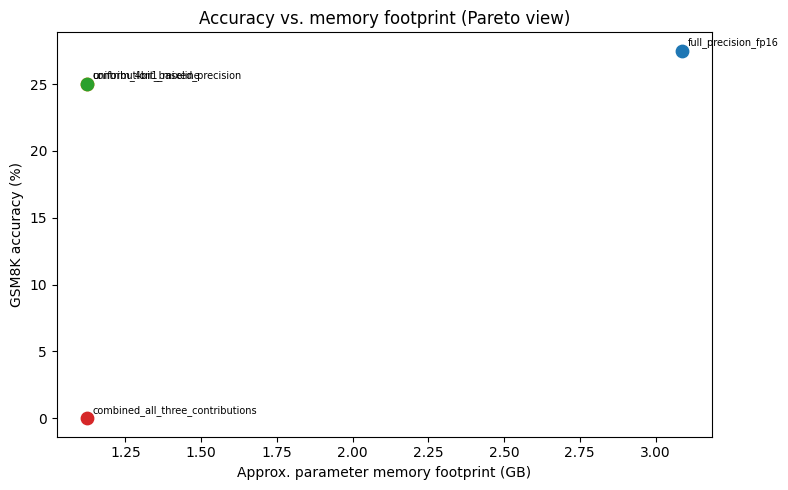

In [ ]:
checkpoint = load_checkpoint()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for key in ["full_precision_fp16", "uniform_4bit_baseline", "contribution1_mixed_precision",
            "contribution3_reasoning_calibrated_4bit", "combined_all_three_contributions"]:
    r = checkpoint.get(key, {})
    if "approx_mem_gb" in r and "accuracy" in r:
        ax.scatter(r["approx_mem_gb"], r["accuracy"], s=80)
        ax.annotate(key, (r["approx_mem_gb"], r["accuracy"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Approx. parameter memory footprint (GB)")
ax.set_ylabel("GSM8K accuracy (%)")
ax.set_title("Accuracy vs. memory footprint (Pareto view)")
plt.tight_layout()
plt.show()   # displayed inline only -- not saved to a separate file

## 10. Ablation: mixed-precision layer budget `K` (Contribution 1)

3 budget points on a smaller eval subset to keep GPU cost modest; each point is checkpointed
individually so a disconnect only loses the point in progress, not the whole ablation.


In [ ]:
checkpoint = load_checkpoint()
sensitivities = get_shared(checkpoint, "sensitivities", "Section 4")
ranked_layers = sorted(range(len(sensitivities)), key=lambda i: -sensitivities[i])

ablation_checkpoint_key = "ablation_mixed_precision_budget"
if ablation_checkpoint_key not in checkpoint:
    checkpoint[ablation_checkpoint_key] = {}

ablation_eval_subset = eval_set[:20]   # smaller subset specifically for the ablation

for frac in [0.0, 0.25, 0.5]:
    frac_key = str(frac)
    if frac_key in checkpoint[ablation_checkpoint_key]:
        print(f"k_frac={frac} already checkpointed -- skipping.")
        continue
    k = max(0, int(len(sensitivities) * frac))
    layer_subset = ranked_layers[:k] if k > 0 else None
    print(f"Loading model for ablation point k_frac={frac} (k={k} layers)...")
    model = load_4bit(skip_layer_ids=layer_subset)
    res = evaluate_model(model, ablation_eval_subset, f"ablation_k={k}")
    checkpoint[ablation_checkpoint_key][frac_key] = {"k_layers": k, "accuracy": res["accuracy"]}
    save_checkpoint(checkpoint)
    del model
    free_gpu()

print("\n--- Ablation results (mixed-precision layer budget) ---")
for frac_key, res in sorted(checkpoint[ablation_checkpoint_key].items(), key=lambda x: float(x[0])):
    print(f"frac={frac_key:>5s}  k_layers={res['k_layers']:>2d}  accuracy={res['accuracy']:.1f}%")

Loading model for ablation point k_frac=0.0 (k=0 layers)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 11. Notes

- **Every cell above is now independently resumable.** Each one starts by reloading `checkpoint
  = load_checkpoint()` from Drive and recomputing any derived value it needs from that dict, so
  it no longer matters whether the kernel restarted, cells ran out of order, or you're returning
  to this notebook on a different day — nothing depends on in-memory state from another cell.
- **If you still hit the free-tier usage cap:** lower `N_EVAL` (Section 2) and the ablation's
  `ablation_eval_subset` size further, or space the run across two days — the checkpoint means
  the second day continues exactly where the first left off.
- **To force a clean re-run** (e.g. after changing `N_EVAL`), delete the checkpoint file:
  `os.remove(CHECKPOINT_PATH)`.
- **Threats to validity** (activation-clamping as a PTQ-recalibration proxy, single model
  family, small eval N for free-tier reproducibility) are discussed in the companion
  manuscript's Section 6 and are unchanged by these bug fixes.
